# AI Dance Data Comparison Tool (v3)
---
這個工具專門用於**跨資料夾數據對比**。它可以幫助您確認不同的數據來源（data1, data2...）究竟有多相似，並找出哪些數據集是重複的。

### 本工具功能：
1. **自動掃描**：偵測所有 `data*` 資料夾。
2. **波形疊加圖**：將所有能量曲線畫在同一張圖上進行視覺對比。
3. **相似度矩陣**：計算數據間的相關係數（Correlation）。
4. **自動化診斷**：標出數值幾乎完全相同的「重複資料夾」。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

# ========================
# 1. 自動偵測資料夾
# ========================
base_path = Path(".")
data_folders = sorted([f.name for f in base_path.glob("data*") if f.is_dir()])

print(f"偵測到共 {len(data_folders)} 個資料夾：")
print(data_folders)

偵測到共 10 個資料夾：
['data', 'data1', 'data2', 'data3', 'data4', 'data5', 'data6', 'data7', 'data8', 'data9']


In [2]:
# ========================
# 2. 多資料集加載 (以 Energy 為例)
# ========================
all_energy = {}
min_length = float('inf')

for folder in data_folders:
    csv_path = base_path / folder / "energy.csv"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        # 儲存能量數據
        all_energy[folder] = df['energy'].values
        min_length = min(min_length, len(df))
    else:
        print(f"[Skip] {folder} 找不到 energy.csv")

# 統一長度以便對比 (截斷至相同 Frame)
energy_df = pd.DataFrame({
    name: vals[:min_length] for name, vals in all_energy.items()
})

print(f"\n數據讀取完成。對比長度：{min_length} 幀。")
display(energy_df.head())


數據讀取完成。對比長度：225 幀。


,data,data1,data2,data3,data4,data5,data6,data7,data8,data9
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1.069188,1.066098,1.068033,1.068631,1.065507,1.068728,1.067551,1.065871,1.067025,1.066065
2,0.869008,0.864236,0.858524,0.858262,0.863404,0.868772,0.858468,0.862593,0.868415,0.863358
3,2.478168,2.495597,2.484093,2.485212,2.495328,2.480342,2.484650,2.494613,2.482161,2.494865
4,3.369318,3.349454,3.347062,3.347135,3.348729,3.370260,3.346652,3.348433,3.369625,3.348845


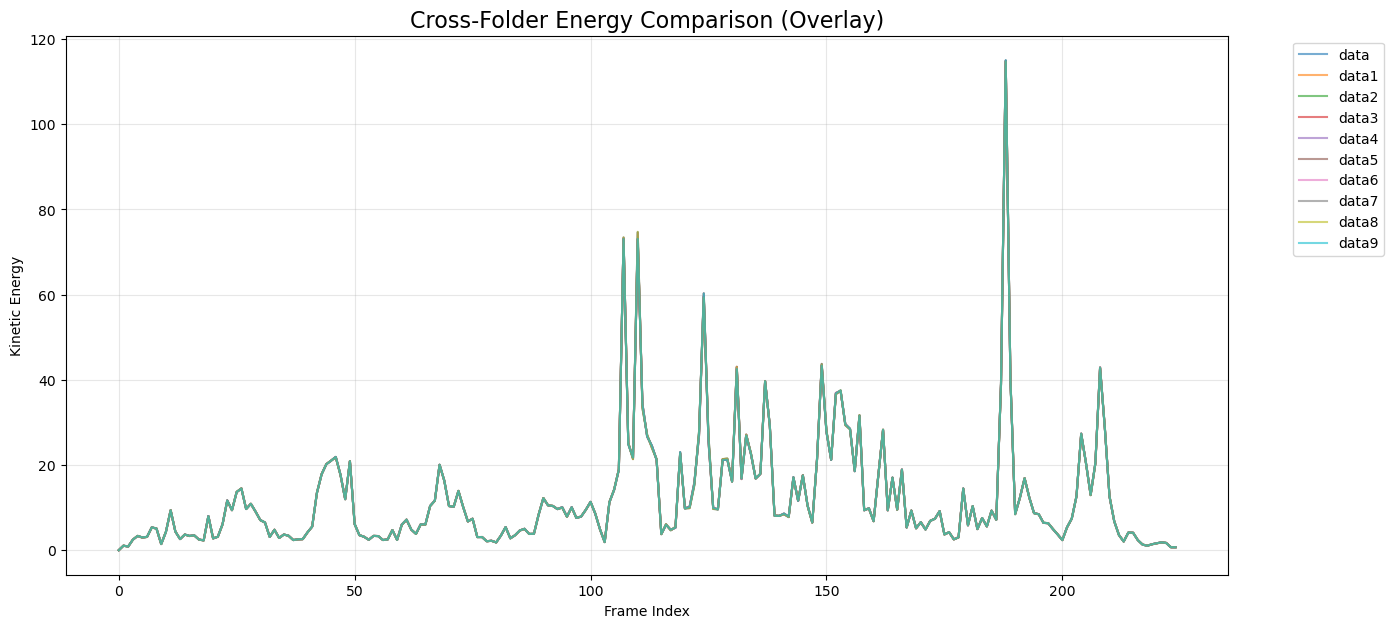

圖表已儲存至 output/v3_comparison_overlay.png


In [3]:
# ========================
# 3. 視覺化對比：波形疊加圖
# ========================
plt.figure(figsize=(15, 7))

for column in energy_df.columns:
    plt.plot(energy_df[column], label=column, alpha=0.6, linewidth=1.5)

plt.title("Cross-Folder Energy Comparison (Overlay)", fontsize=16)
plt.xlabel("Frame Index")
plt.ylabel("Kinetic Energy")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

output_dir = Path("./output")
output_dir.mkdir(exist_ok=True)
plt.savefig(output_dir / "v3_comparison_overlay.png", bbox_inches='tight', dpi=150)
plt.show()

print("圖表已儲存至 output/v3_comparison_overlay.png")

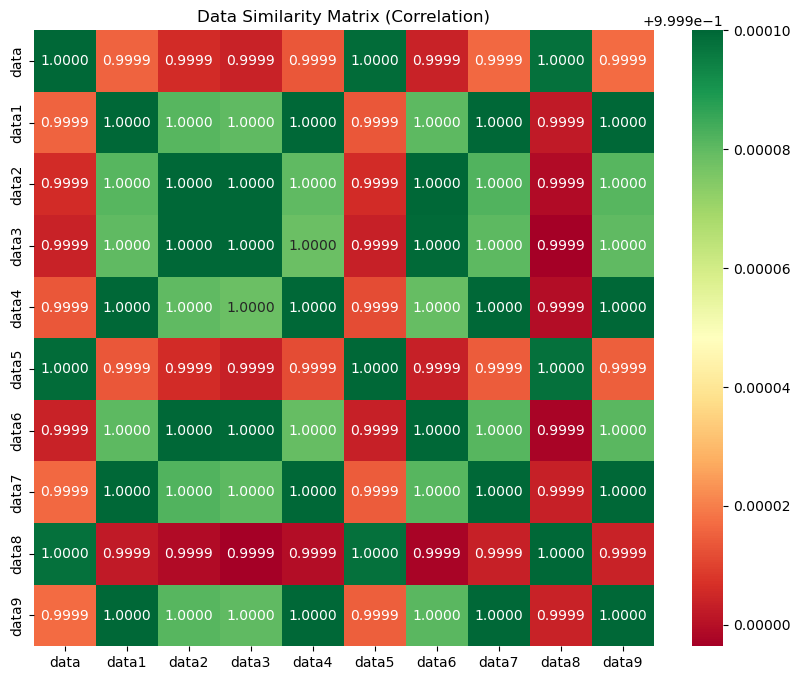

相似度矩陣已儲存。

--- [ 重複數據診斷報告 ] ---
[!] data 與 data1 幾乎完全相同 (相似度: 0.999916)
[!] data 與 data2 幾乎完全相同 (相似度: 0.999906)
[!] data 與 data3 幾乎完全相同 (相似度: 0.999904)
[!] data 與 data4 幾乎完全相同 (相似度: 0.999913)
[!] data 與 data5 幾乎完全相同 (相似度: 0.999999)
[!] data 與 data6 幾乎完全相同 (相似度: 0.999904)
[!] data 與 data7 幾乎完全相同 (相似度: 0.999917)
[!] data 與 data8 幾乎完全相同 (相似度: 0.999998)
[!] data 與 data9 幾乎完全相同 (相似度: 0.999917)
[!] data1 與 data2 幾乎完全相同 (相似度: 0.999981)
[!] data1 與 data3 幾乎完全相同 (相似度: 0.999980)
[!] data1 與 data4 幾乎完全相同 (相似度: 1.000000)
[!] data1 與 data5 幾乎完全相同 (相似度: 0.999914)
[!] data1 與 data6 幾乎完全相同 (相似度: 0.999980)
[!] data1 與 data7 幾乎完全相同 (相似度: 1.000000)
[!] data1 與 data8 幾乎完全相同 (相似度: 0.999902)
[!] data1 與 data9 幾乎完全相同 (相似度: 1.000000)
[!] data2 與 data3 幾乎完全相同 (相似度: 1.000000)
[!] data2 與 data4 幾乎完全相同 (相似度: 0.999980)
[!] data2 與 data5 幾乎完全相同 (相似度: 0.999906)
[!] data2 與 data6 幾乎完全相同 (相似度: 1.000000)
[!] data2 與 data7 幾乎完全相同 (相似度: 0.999982)
[!] data2 與 data8 幾乎完全相同 (相似度: 0.999899)
[!] data2 與 data9 幾乎完全相同 (相似度: 0.9

In [4]:
# ========================
# 4. 相似度分析 (Correlation Matrix)
# ========================
corr_matrix = energy_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="RdYlGn", fmt=".4f")
plt.title("Data Similarity Matrix (Correlation)")
plt.savefig(output_dir / "v3_similarity_matrix.png")
plt.show()

print("相似度矩陣已儲存。")

# 找出極度相似的對象 (相關係數 > 0.999)
print("\n--- [ 重複數據診斷報告 ] ---")
redundant_found = False
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.999:
            print(f"[!] {corr_matrix.columns[i]} 與 {corr_matrix.columns[j]} 幾乎完全相同 (相似度: {corr_matrix.iloc[i, j]:.6f})")
            redundant_found = True

if not redundant_found:
    print("所有數據集皆有明顯差異。")